In [1]:

from spm_agent.states.image_analysis_state import AnalysisState
from langgraph.graph import StateGraph, START, END

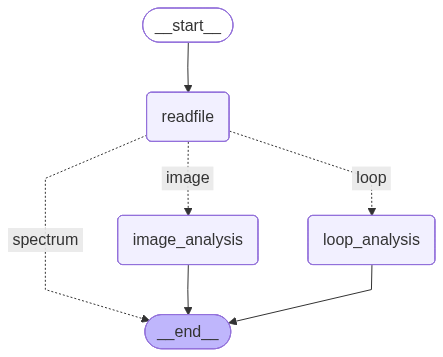

In [2]:
from spm_agent.graphs.analysis_graph import build_analysis_graph

EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
]

EXPERIMENT_CONTEXT = (
        "Dual AC Resonance Tracking PFM: two drive frequencies f1/f2 straddle the "
        "contact resonance; channel suffixes 1/2 index these drives, NOT harmonics. "
        "Frequency channel = tracked contact resonance."
)

im_graph = build_analysis_graph()
im_graph

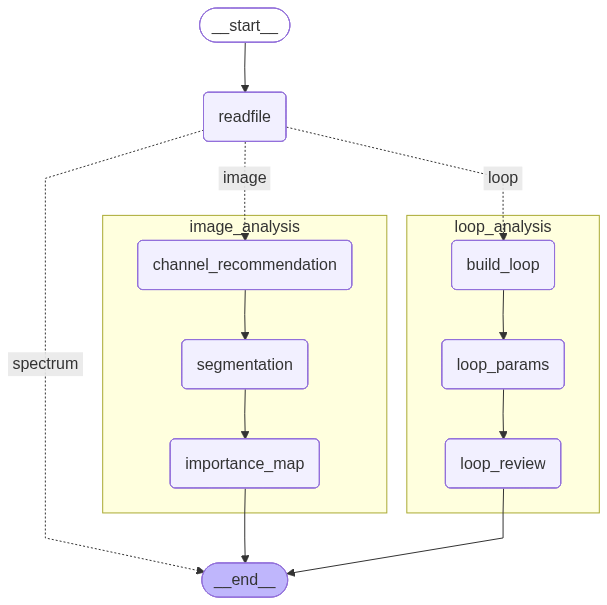

In [3]:
from IPython.display import Image
Image(im_graph.get_graph(xray=True).draw_mermaid_png())

In [4]:
res = await im_graph.ainvoke({"file_path": r"/Users/borisslautin/Downloads/PLZT/PLZT_0005.ibw"})

loop


In [5]:
res

{'file_path': '/Users/borisslautin/Downloads/PLZT/PLZT_0005.ibw',
 'file_channels': {'Channel_000': {'title': 'Raw',
   'units': 'm',
   'data_type': 'SPECTRUM',
   'shape': [6431],
   'stats': {'ok': True,
    'min': -4.951625598437204e-08,
    'max': -4.0185721417174136e-08,
    'mean': -4.802734146302326e-08,
    'std': 2.4046825959462848e-09,
    'p01': -4.945691181035272e-08,
    'p99': -4.0752819785438994e-08},
   'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/Raw.png',
   'array_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/Raw.npy'},
  'Channel_001': {'title': 'Defl',
   'units': 'V',
   'data_type': 'SPECTRUM',
   'shape': [6431],
   'stats': {'ok': True,
    'min': 2.9190838191084367e-08,
    'max': 9.278062407247489e-08,
    'mean': 8.85415322106484e-08,
    'std': 5.880446076766199e-09,
    'p01': 7.879397685428558e-08,
    'p99': 9.219635828117134e-08},
   'preview_path': '/Us

In [5]:
res = await im_graph.ainvoke({"file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw",
                              "experiment_tasks": EXPERIMENT_TASKS,
                              "experiment_context": EXPERIMENT_CONTEXT
                              })

image


In [18]:
from pprint import pprint

pprint(res['importance_maps'][0]['reasoning'])

('All outputs are verified and saved. Here is the summary:\n'
 '\n'
 '---\n'
 '\n'
 '## Summary of Scoring Criteria\n'
 '\n'
 'Five non-redundant criteria (all pairwise |corr| < 0.9, max observed = '
 '0.624) were designed to identify the most informative locations for '
 'comparing ferroelectric switching **inside domains** versus **near domain '
 'walls**:\n'
 '\n'
 '1. **PFM Amplitude (w=1.5)** — The average DART amplitude from both drive '
 'frequencies reflects local electromechanical coupling strength. Higher '
 'amplitude means a larger piezoresponse signal, directly improving the '
 'signal-to-noise ratio of switching events detected in local PFM spectroscopy '
 'at any location.\n'
 '\n'
 '2. **Domain Interior (w=2.0)** — A distance-transform score computed only '
 'within the segmented domain mask: pixels deep inside a domain are '
 'unambiguously in a single-polarization state, far from wall-mediated '
 'nucleation fields. These are the ideal reference sites for measuring '


In [7]:
import json
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def plot_importance_results(res, task_index=None, save_dir=None, dpi=200):
    """One slide-ready figure per task: component maps, final importance map,
    weights, and the agent's reasoning. `res` = AnalysisState after importance_map_node.

    task_index: int to render one task, None for all.
    save_dir:   if given, saves importance_task_{i}.png there.
    Returns list of figures."""
    entries = res["importance_maps"]
    idxs = range(len(entries)) if task_index is None else [task_index]
    figs = []

    for i in idxs:
        e = entries[i]
        comps = np.load(e["components_path"])                     # (K,H,W)
        final = np.load(e["importance_map_path"])
        meta  = json.loads(Path(e["components_json_path"]).read_text())
        names, weights = meta["names"], np.asarray(meta["weights"], float)
        rationale = meta.get("rationale", [""] * len(names))
        K = comps.shape[0]

        fig = plt.figure(figsize=(4.2 * (K + 1), 8.2))
        gs = GridSpec(2, K + 1, figure=fig, height_ratios=[1.6, 1.0],
                      hspace=0.32, wspace=0.25)

        # --- top row: components + final map ---
        for j in range(K):
            ax = fig.add_subplot(gs[0, j])
            im = ax.imshow(comps[j], cmap="hot", vmin=0, vmax=1)
            ax.set_title(f"C{j+1}: {names[j]}\nw = {weights[j]:.2f}", fontsize=11)
            ax.axis("off")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

        ax = fig.add_subplot(gs[0, K])
        im = ax.imshow(final, cmap="inferno", vmin=0, vmax=100)
        ax.set_title("IMPORTANCE MAP\n(weighted sum)", fontsize=12, fontweight="bold")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        for s in ax.spines.values():
            s.set_visible(True); s.set_linewidth(2)

        # --- bottom left: weights bar chart ---
        axw = fig.add_subplot(gs[1, 0])
        y = np.arange(K)[::-1]
        axw.barh(y, weights, color="#c0392b", alpha=0.85)
        axw.set_yticks(y, [f"C{j+1}" for j in range(K)], fontsize=10)
        axw.set_xlim(0, max(weights) * 1.25)
        for yj, w in zip(y, weights):
            axw.text(w + 0.01, yj, f"{w:.2f}", va="center", fontsize=10)
        axw.set_title("Criteria weights", fontsize=11)
        axw.spines[["top", "right"]].set_visible(False)

        # --- bottom right: text panel ---
        axt = fig.add_subplot(gs[1, 1:])
        axt.axis("off")
        lines = [f"TASK: {e['experiment_task']}", ""]
        for j, (n, r) in enumerate(zip(names, rationale)):
            lines += textwrap.wrap(f"C{j+1} {n}: {r}", 110)
        lines.append("")
        lines += textwrap.wrap("AGENT: " + e.get("reasoning", ""), 110)[:8]  # cap length
        axt.text(0, 1, "\n".join(lines), va="top", ha="left", fontsize=10.5,
                 family="sans-serif", linespacing=1.45, transform=axt.transAxes)

        fig.suptitle(f"Importance map — task {i}", fontsize=14, fontweight="bold", y=0.99)

        if save_dir:
            Path(save_dir).mkdir(parents=True, exist_ok=True)
            fig.savefig(Path(save_dir) / f"importance_task_{i}.png",
                        dpi=dpi, bbox_inches="tight")
        figs.append(fig)

    return figs

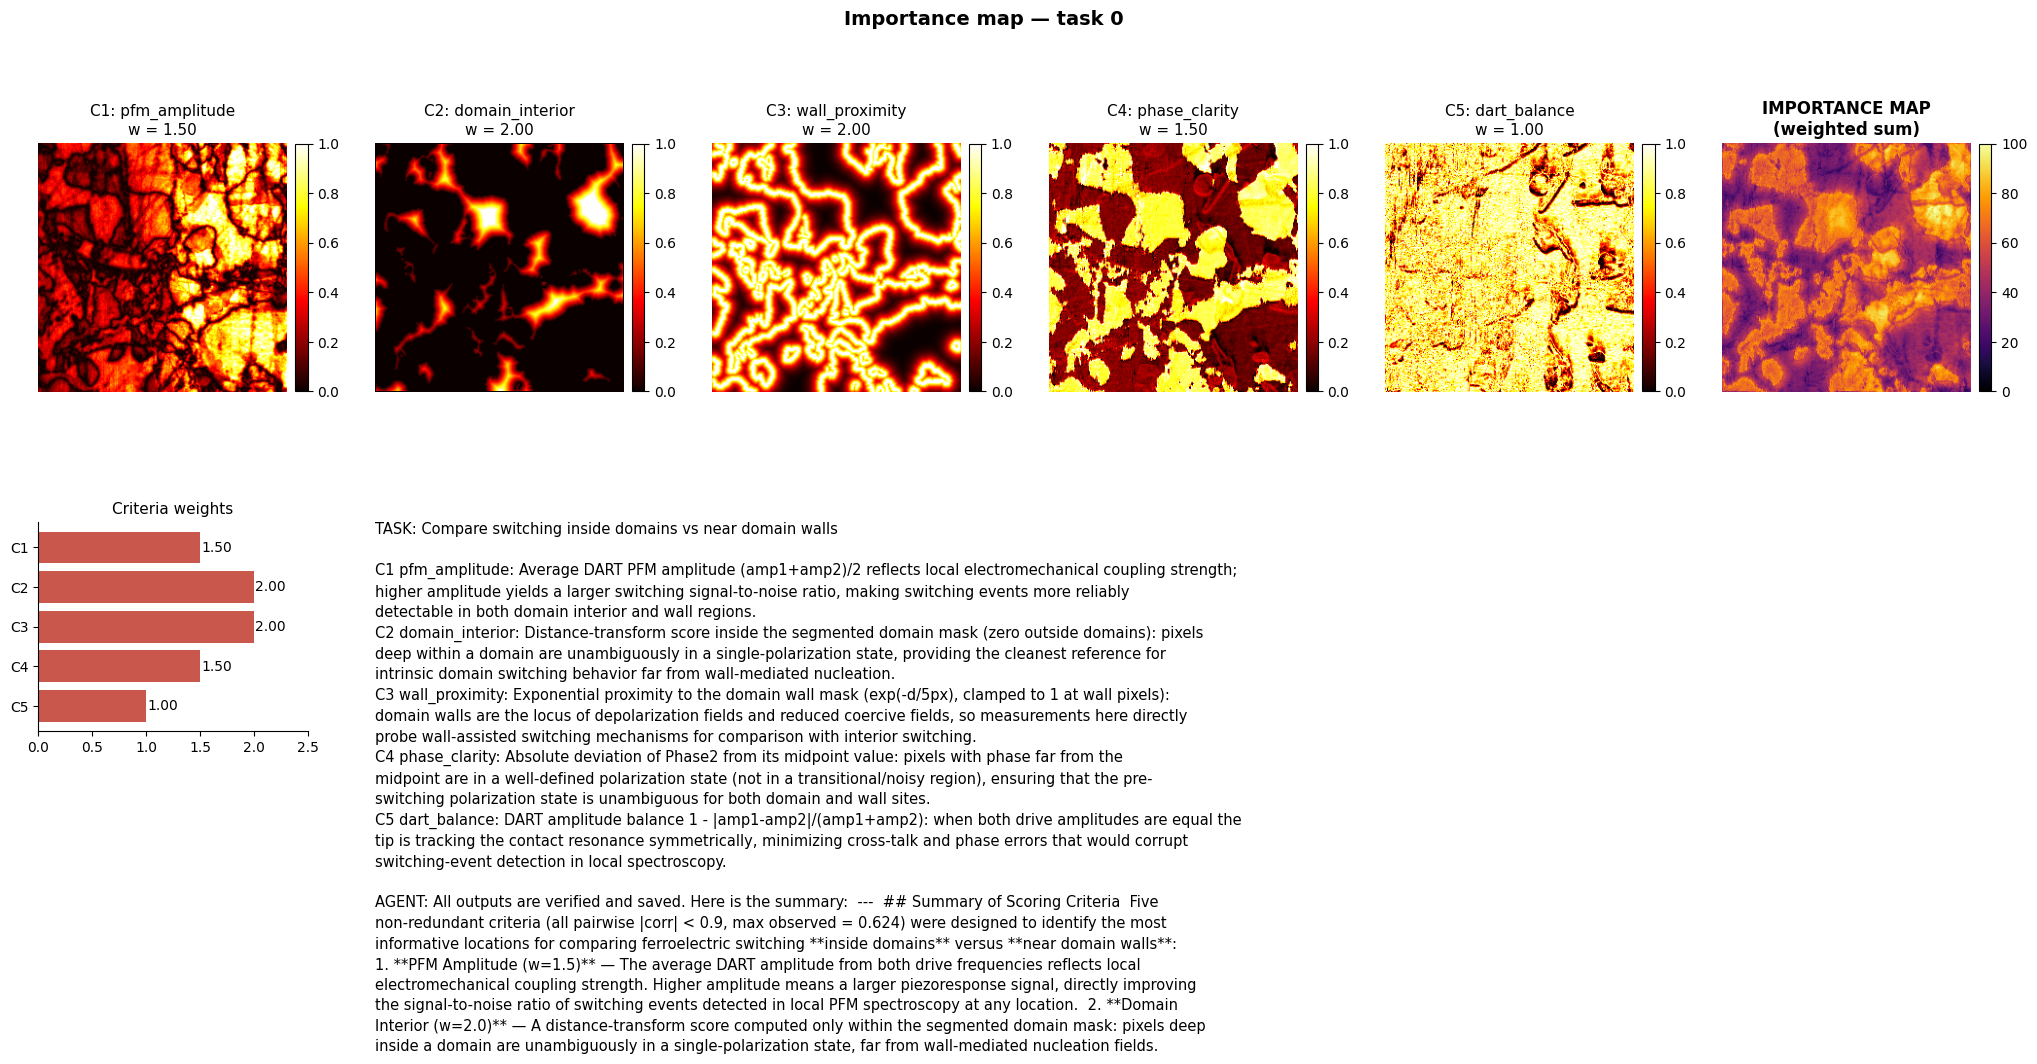

In [8]:
%matplotlib inline
plot_importance_results(res)
plt.show()